In [4]:
!nvidia-smi

Sun May  3 05:28:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   66C    P0             31W /   72W |    1537MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# 1. 구글 드라이브 연동 (마운트)
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
import pandas as pd

# 2. 파이썬 파일들이 있는 드라이브 경로 설정 및 시스템 패스에 추가
project_path = '/content/drive/MyDrive/GCY6902_01_TFT/'
sys.path.append(project_path)

from run_regression import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

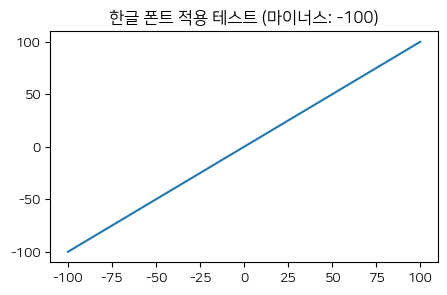

In [2]:
# 1. 우분투 환경에 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. 설치된 폰트를 Matplotlib 메모리에 직접 추가 (런타임 재시작 방지)
font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
for fpath in font_files:
    fm.fontManager.addfont(fpath)

# 3. 기본 폰트 및 설정 변경
plt.rc('font', family='NanumSquare') # 폰트 이름 설정 (NanumGothic, NanumBarunGothic 등 사용 가능)
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호 깨짐 방지

# 4. 테스트용 코드 (한글이 잘 나오는지 확인)
plt.figure(figsize=(5, 3))
plt.title("한글 폰트 적용 테스트 (마이너스: -100)")
plt.plot([-100, 0, 100], [-100, 0, 100])
plt.show()

In [6]:
# 3. 데이터 로드 (업로드한 데이터 파일 이름에 맞게 수정)
file_path = os.path.join(project_path, 'data/df_260503.parquet')
df = pd.read_parquet(file_path)
var_list = ['Open', 'High', 'Low', 'Close', 'Volume', 'DXY', 'GOLD', 'NASDAQ']

====target : 4 Close=====
train: 20240101~20260130 자료 추출 중 : 239820
validation set : 20260127~20260331 자료 추출 중 : 27766
test set : 20260208~20260412 자료 추출 중 : 27871
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.064377 | val_loss=0.055086 | test_loss=0.056520 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030529_1_SEQ30/Close_tft_test_260503.pt
***[TFT Epoch:002] train_loss=0.061571 | val_loss=0.041446 | test_loss=0.045325 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030529_1_SEQ30/Close_tft_test_260503.pt
***[TFT Epoch:003] train_loss=0.059594 | val_loss=0.039020 | test_loss=0.041399 | lr=3.99e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030529_1_SEQ30/Close_tft_test_260503.pt
***[TFT Epoch:004] train_loss=0.056531 | val_loss=0.037796 | test_loss=0.041252 | lr=3.31e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030529_1_SEQ30/Close_tft_te

/content/drive/MyDrive/GCY6902_01_TFT/run_regression.py:501: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/run_regression.py:543: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/run_regression.py:551: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) NanumSquare.
  fig.canvas.draw()
/content/drive/MyDrive/GCY6902_01_TFT/run_regression.py:600: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) NanumSquare.
  plt.savefig(save_path)


==========★★★★★최종output★★★★★==========


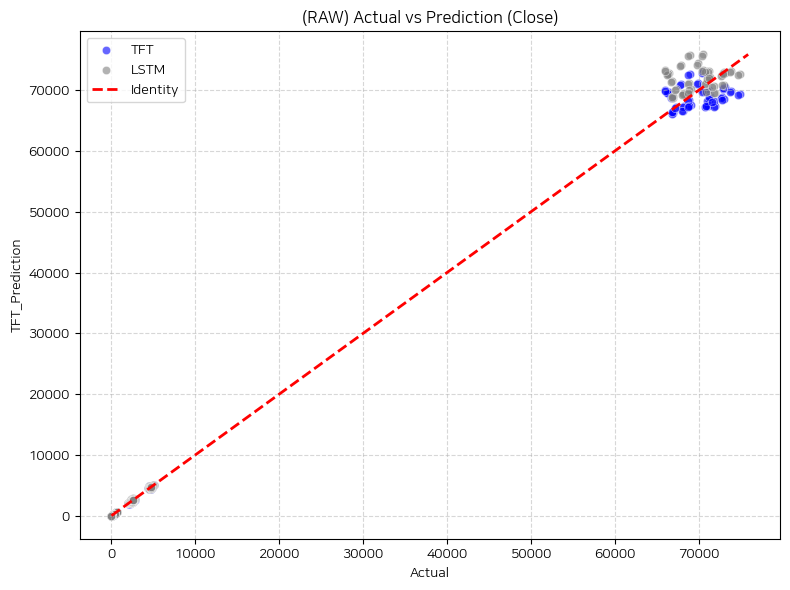

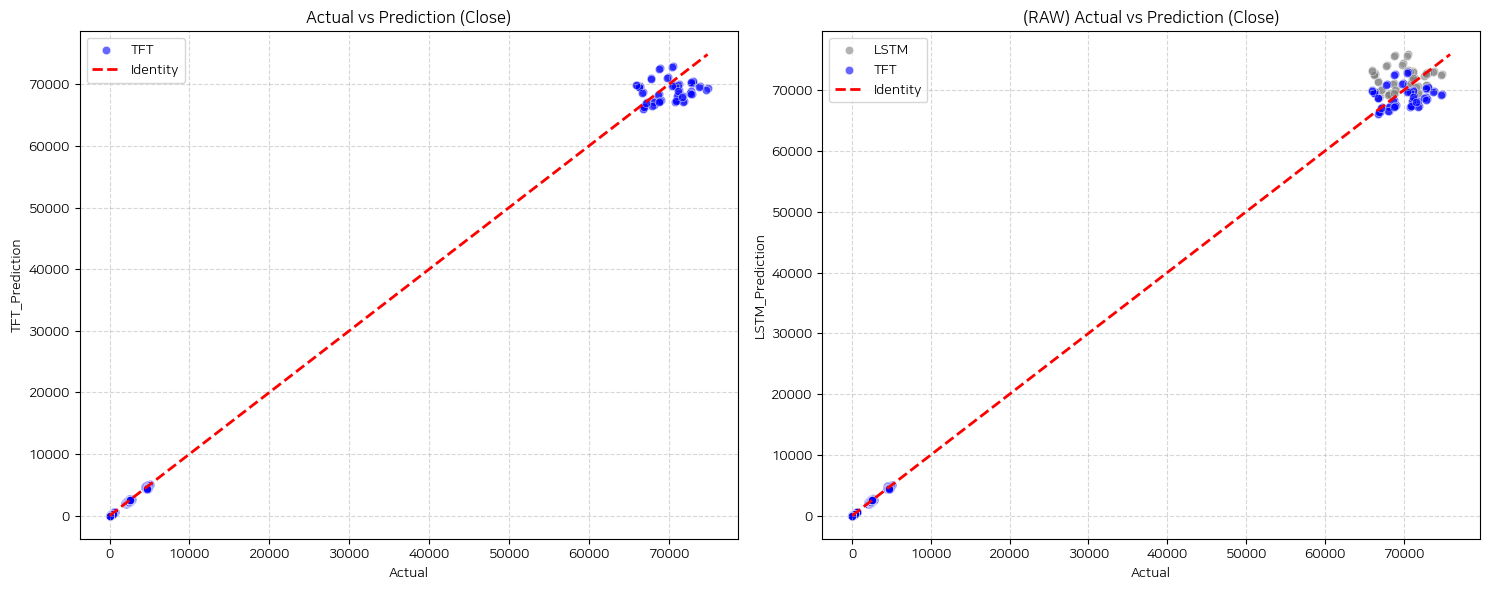

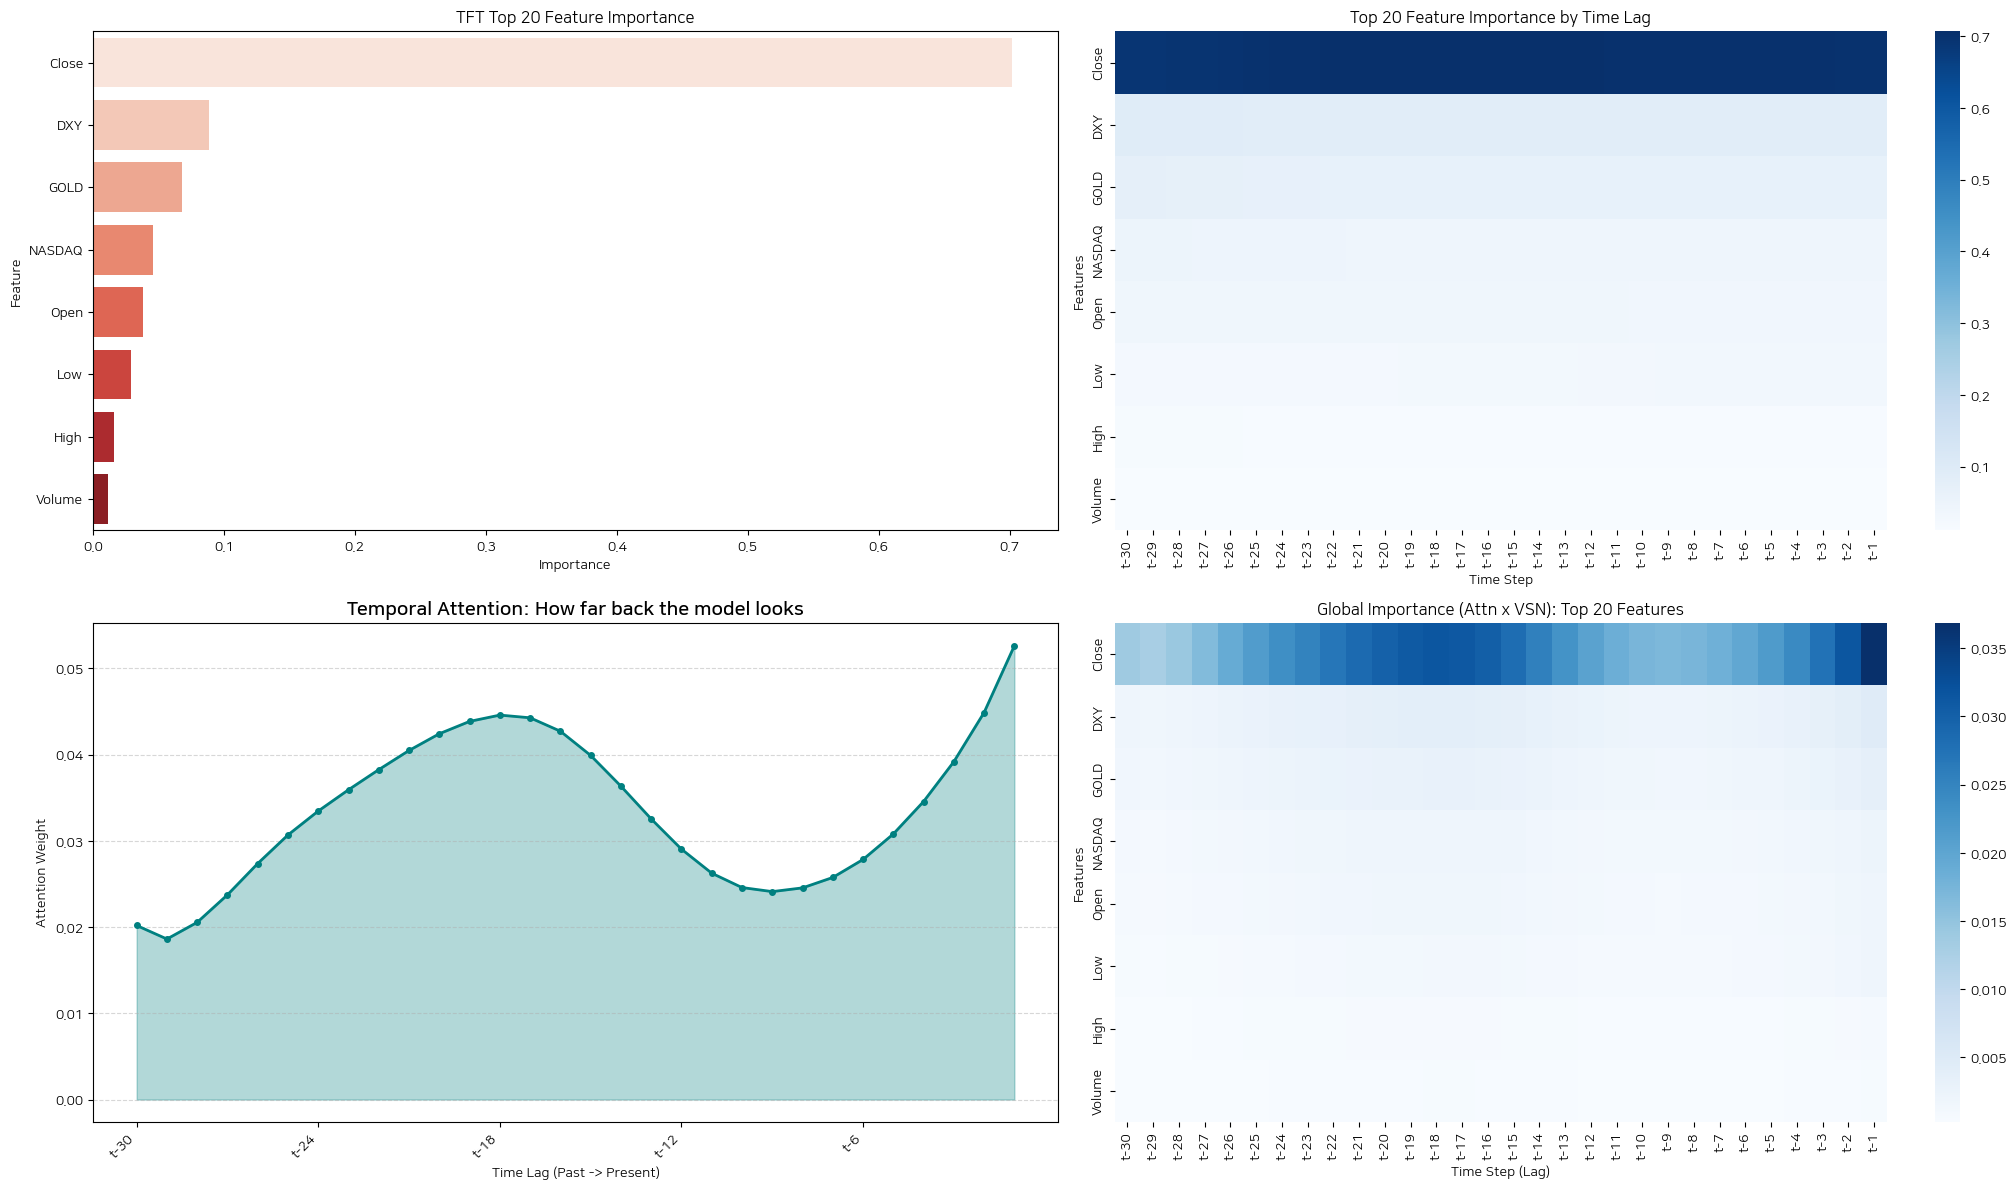

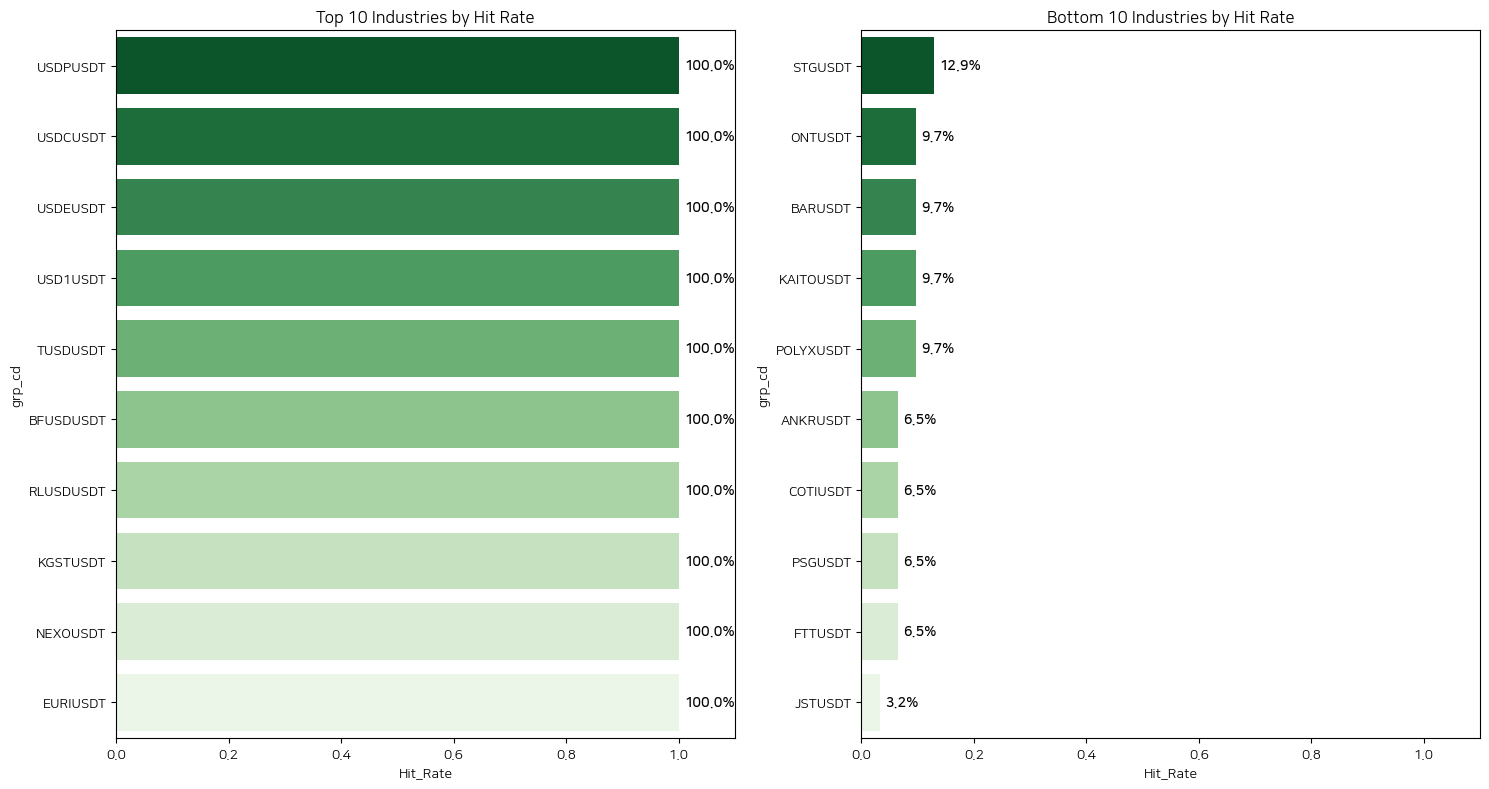

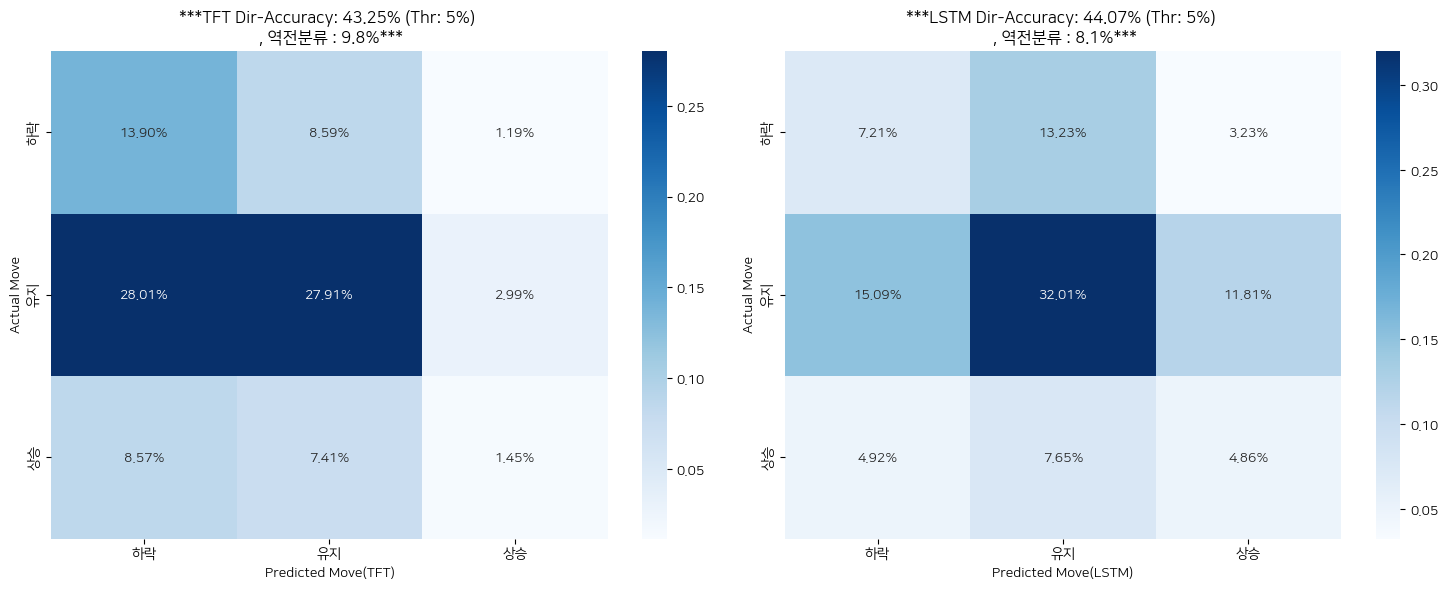

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) NanumSquare.
  fig.canvas.print_figure(bytes_io, **kw)


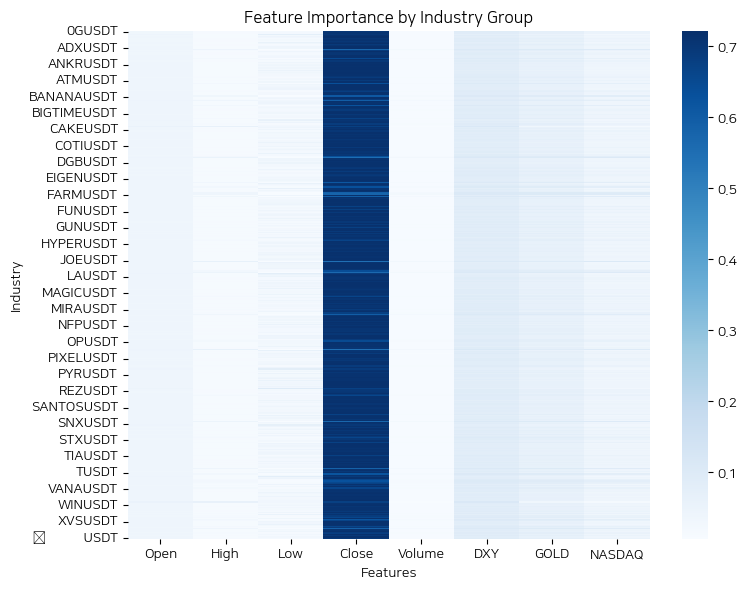

In [ ]:
SEQ = 30
target = "Close" 
config_dict = {'d_model':8,
    'hidden_dim': 64,#128
    'lstm_hidden': 64,#128
    'n_heads': 4,
    'dropout': 0.2,

    'past_vars': len(var_list),
    'known_vars':  1,   # 예: time index, month, quarter 등
    'static_vars':  1,
    'output_mode': "regression"  # "regression" | "binary" | "multiclass"
}
for SEQ in [30]: # 시퀀스 길이 실험
    outdir = project_path+"output/" + datetime.now().strftime('%y%m%d%H%M')+f"_1_SEQ{str(SEQ).zfill(2)}/"
    os.mkdir(outdir)

    fit_and_out(
        df,
        target,
        outdir,
        config_dict,
        var_list=var_list,
        grp_cd="Symbol",
        epochs=50,
        patience=10,
        threshold=0.02,
        trk_start_dt='20240101',
        seq_length=SEQ,
        dt_cut='20260331',
        tgt_gap=3,
        seed=42,
        train_yn=1
    )

In [ ]:
# import sys

# # 메모리에 기존 코드가 남아있다면 삭제해버림
# if 'run_regression' in sys.modules:
#     del sys.modules['run_regression']
# if 'train_tft' in sys.modules:
#     del sys.modules['train_tft']

# # 그리고 나서 새로 깔끔하게 import
# from run_regression import fit_and_out
# fit_and_out(
#         df,
#         target,
#         outdir,
#         config_dict,
#         var_list=var_list,
#         grp_cd="Symbol",
#         epochs=50,
#         patience=10,
#         threshold=0.05,
#         trk_start_dt='20240101',
#         seq_length=SEQ,
#         dt_cut='20260201',
#         tgt_gap=3,
#         seed=42,
#         train_yn=0
#     )

====target : 4 Close=====
train: 20240101~20251203 자료 추출 중 : 215223
validation set : 20251031~20260201 자료 추출 중 : 39694
test set : 20260109~20260412 자료 추출 중 : 40735
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.065490 | val_loss=0.058933 | test_loss=0.102313 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030155_1_SEQ60/Close_tft_test_260503.pt
***[TFT Epoch:002] train_loss=0.061136 | val_loss=0.058463 | test_loss=0.095483 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030155_1_SEQ60/Close_tft_test_260503.pt
***[TFT Epoch:003] train_loss=0.058870 | val_loss=0.055778 | test_loss=0.091379 | lr=3.99e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030155_1_SEQ60/Close_tft_test_260503.pt
***[TFT Epoch:004] train_loss=0.055384 | val_loss=0.055005 | test_loss=0.084688 | lr=3.31e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/output/2605030155_1_SEQ60/Close_tft_te

: 